# Experimento A — configuración 4×4 con impacto y perfil *anytime*

**TTAP: 4 helicópteros, 4 áreas de demanda y 20–60 tareas**  
**Copia metodológicamente ampliada del notebook `20260621_Escalamiento_inicial.ipynb` (commit `2945b2d…`)**

Este notebook implementa las decisiones cerradas para responder las observaciones metodológicas:

1. **Magnitud humanitaria (q_i)**: en tareas médicas, `med` es el número de personas con una condición médica que requieren evacuación; en personal, `pers` es el número de personas transportadas; en carga, `load` es la carga entregada.
2. **Prioridad compensatoria**: se conservan los pesos del notebook original (`medical=2.0`, `personnel=1.5`, `cargo=1.0`). No es una prioridad lexicográfica.
3. **Objetivo común**: MILP y heurísticas evalúan exactamente
   \[
   b_i(t)=\frac{w_i q_i S_i(t)}{\sum_j w_j q_j}.
   \]
4. **Tres políticas constructivas**:
   - `Greedy-Benefit`;
   - `Greedy-Density-Operational`: beneficio dividido por vuelo hacia la tarea + servicio;
   - `Greedy-Density-Cycle`: beneficio dividido por vuelo + servicio + retorno + recuperación.
5. **Perfil anytime de HiGHS**: presupuestos de 1, 5, 15 y 60 segundos en modo `paper`, separando calidad primal, cota dual, *MIP gap* y certificación.
6. **Recuperación obligatoria**: ninguna tarea heurística se acepta si impide regresar a base y recuperar dentro de (T_{\max}).

La severidad clínica no se incorpora todavía como parámetro independiente: la urgencia queda representada por (S_i(t)). Esto evita contar la gravedad dos veces. El notebook deja esta simplificación explícita para una extensión posterior.

### Ejecución

- Mantenga `RUN_MODE = "quick"` para validar localmente la instalación y una instancia.
- Cambie a `RUN_MODE = "paper"` para ejecutar las 30 semillas, los cinco tamaños y los presupuestos completos.
- Dependencias: `numpy`, `pandas`, `scipy` y `matplotlib`; `psutil` es opcional y solo se usa para informar la RAM.


In [3]:
pip install scipy

   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/20.3 MB 205.9 kB/s eta 0:01:34
Resuming download scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl (1.0 MB/20.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 929.6 kB/s  0:00:20m0:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
# ============================================================
# 01. IMPORTS, ENVIRONMENT AND GLOBAL CONFIGURATION
# ============================================================

import math
import os
import platform
import sys
import time
from collections import Counter, defaultdict, deque
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import Bounds, LinearConstraint, milp
from scipy.sparse import coo_matrix

try:
    import psutil
except ImportError:
    psutil = None

if not hasattr(scipy.optimize, "milp"):
    raise RuntimeError("This notebook requires scipy.optimize.milp (SciPy >= 1.9).")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)

# -----------------------------
# Execution mode
# -----------------------------
RUN_MODE = "quick"  # "quick" or "paper"

if RUN_MODE == "quick":
    ACTIVE_TASK_COUNTS = [20]
    ACTIVE_SEEDS = [1]
    ACTIVE_HIGHS_BUDGETS = [600]
elif RUN_MODE == "paper":
    ACTIVE_TASK_COUNTS = [20, 30, 40, 50, 60]
    ACTIVE_SEEDS = list(range(1, 31))
    ACTIVE_HIGHS_BUDGETS = [1, 5, 15, 60, 600]
else:
    raise ValueError("RUN_MODE must be 'quick' or 'paper'.")

TASK_COUNTS = [20, 30, 40, 50, 60]
INSTANCE_SEEDS = list(range(1, 31))
MAX_TASKS = max(TASK_COUNTS)

TASK_GENERATOR_VERSION = "matched_v3_impact_anytime"
TASK_PROFILE_STREAM_ID = 21001
TASK_LOCATION_STREAM_A_ID = 22001

TASK_CLASS_NAMES = np.array(["medical", "personnel", "cargo"])
TASK_CLASS_PROBABILITIES = np.array([0.45, 0.30, 0.25])
VISUAL_REQUIRED_PROBABILITY = 0.40

DEFAULT_PARAMS = {
    "SERVICE_TIME": 6.0,
    "RECOVERY_TIME": 2.0,
    "TMAX": 200.0,
    "ALPHA": 0.1,
    "TIME_UNIT": 1.0,
    "USE_PRIORITY_WEIGHTS": True,
    "PRIORITY_WEIGHTS": {
        "medical": 2.0,
        "personnel": 1.5,
        "cargo": 1.0,
    },
    # Maximum class magnitude used only to make q_i dimensionless.
    "IMPACT_REFERENCES": {
        "medical": 3.0,      # medical evacuees
        "personnel": 3.0,    # transported people
        "cargo": 500.0,      # kg delivered
    },
}

OUTPUT_DIR = Path("ttap_experiment_A_4x4_impact_anytime")
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = [
    "Greedy-Benefit",
    "Greedy-Density-Operational",
    "Greedy-Density-Cycle",
] + [f"HiGHS-{budget}s" for budget in ACTIVE_HIGHS_BUDGETS]

METHOD_COLORS = {
    "Greedy-Benefit": "#6C757D",
    "Greedy-Density-Operational": "#2A9D8F",
    "Greedy-Density-Cycle": "#E9C46A",
    **{f"HiGHS-{b}s": "#264653" for b in ACTIVE_HIGHS_BUDGETS},
}


def save_current_figure(name, dpi=220):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Figure saved at:", path)


memory_gb = psutil.virtual_memory().total / (1024 ** 3) if psutil is not None else np.nan
print("Computational environment")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Processor:", platform.processor())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print(f"RAM: {memory_gb:.2f} GB" if np.isfinite(memory_gb) else "RAM: not reported (optional psutil package unavailable)")
print("RUN_MODE:", RUN_MODE)
print("Task counts:", ACTIVE_TASK_COUNTS)
print("Seeds:", ACTIVE_SEEDS)
print("HiGHS budgets:", ACTIVE_HIGHS_BUDGETS)


ModuleNotFoundError: No module named 'scipy'

## 2. Definición matemática del valor humanitario

Para cada tarea (i), se separan tres conceptos:

| Componente | Significado | Código |
|---|---|---|
| (w_i) | prioridad compensatoria de clase | `class_weight` |
| (q_i) | magnitud humanitaria normalizada | `impact` |
| (S_i(t)) | oportunidad temporal al completar en (t) | `satisfaction(...)` |

La magnitud se calcula como

\[
q_i=
\begin{cases}
\text{medical evacuees}_i/3, & i\in I^{medical},\\
\text{people transported}_i/3, & i\in I^{personnel},\\
\text{cargo delivered}_i/500, & i\in I^{cargo}.
\end{cases}
\]

Las referencias son fijas y coinciden con la capacidad máxima del generador. No se usa normalización *min–max* por instancia, por lo que una misma tarea conserva su significado entre escenarios.

El valor potencial es (v_i=w_iq_i), el denominador (V^{\max}=\sum_i v_i), y el valor capturado es

\[
J=\sum_{h}\sum_{a\in A_h^{task}}
\frac{w_{i(a)}q_{i(a)}S_{i(a)}(t_a)}{V^{\max}}x_a.
\]

El denominador no cambia la solución óptima; permite comparar instancias con distinto número de tareas. (J\in[0,1]), y solo alcanza 1 si todas las tareas se completan con satisfacción temporal igual a 1.


In [ ]:
# ============================================================
# 03. SCENARIO GENERATION AND IMPACT METADATA
# ============================================================

def default_nodes():
    return {
        "Base": (0.0, 0.0),
        "A": (10.0, 5.0),
        "B": (20.0, 15.0),
        "C": (30.0, 10.0),
        "D": (40.0, 20.0),
    }


def default_fleet():
    return {
        "H1": {"visual": True,  "load": 500, "med": 3, "pers": 3, "speed": 150},
        "H2": {"visual": False, "load": 500, "med": 3, "pers": 3, "speed": 120},
        "H3": {"visual": True,  "load": 500, "med": 3, "pers": 3, "speed": 140},
        "H4": {"visual": False, "load": 500, "med": 3, "pers": 3, "speed": 160},
    }


def classify_task_priority(task):
    if task["med"] > 0:
        return "medical"
    if task["pers"] > 0:
        return "personnel"
    if task["load"] > 0:
        return "cargo"
    raise ValueError("Task has no positive operational requirement.")


def raw_humanitarian_impact(task, task_class):
    """Physical output used to define q_i; not a resource-cost score."""
    if task_class == "medical":
        return float(task["med"]), "medical evacuees"
    if task_class == "personnel":
        return float(task["pers"]), "people transported"
    if task_class == "cargo":
        return float(task["load"]), "kg delivered"
    raise ValueError(f"Unknown task class: {task_class}")


def assign_task_value_metadata(scenario):
    params = scenario["params"]
    weights = params["PRIORITY_WEIGHTS"]
    references = params["IMPACT_REFERENCES"]
    use_weights = params["USE_PRIORITY_WEIGHTS"]

    for task in scenario["tasks"].values():
        task_class = classify_task_priority(task)
        raw_impact, impact_unit = raw_humanitarian_impact(task, task_class)
        reference = float(references[task_class])
        if reference <= 0:
            raise ValueError("Every impact reference must be positive.")

        task["priority_class"] = task_class
        task["class_weight"] = float(weights[task_class]) if use_weights else 1.0
        task["raw_impact"] = raw_impact
        task["impact_unit"] = impact_unit
        task["impact_reference"] = reference
        task["impact"] = raw_impact / reference
        task["potential_value"] = task["class_weight"] * task["impact"]

    total_potential_value = sum(
        task["potential_value"] for task in scenario["tasks"].values()
    )
    if total_potential_value <= 0:
        raise ValueError("Total potential mission value must be positive.")

    scenario["total_potential_value"] = float(total_potential_value)
    return scenario


def make_reproducible_rng(seed, stream_id):
    return np.random.default_rng(
        np.random.SeedSequence([int(seed), int(stream_id)])
    )


REFERENCE_FLEET = {
    h: {k: v for k, v in data.items() if k != "speed"}
    for h, data in default_fleet().items()
}


def task_is_structurally_feasible(task, fleet=REFERENCE_FLEET):
    return any(
        (not task["visual"] or helo["visual"])
        and helo["load"] >= task["load"]
        and helo["med"] >= task["med"]
        and helo["pers"] >= task["pers"]
        for helo in fleet.values()
    )


def draw_task_profile(rng):
    task_class = str(rng.choice(TASK_CLASS_NAMES, p=TASK_CLASS_PROBABILITIES))
    visual = bool(rng.random() < VISUAL_REQUIRED_PROBABILITY)

    if task_class == "medical":
        load = int(rng.choice(np.arange(50, 501, 50)))
        med = int(rng.integers(1, 4))
        pers = int(rng.integers(0, 4))
    elif task_class == "personnel":
        load = int(rng.choice(np.arange(50, 501, 50)))
        med = 0
        pers = int(rng.integers(1, 4))
    else:
        load = int(rng.choice(np.arange(100, 501, 50)))
        med = 0
        pers = 0

    t_opt = int(rng.integers(8, 36))
    t_eff = t_opt + int(rng.integers(12, 27))
    t_ineff = t_eff + int(rng.integers(20, 61))

    task = {
        "visual": visual,
        "load": load,
        "med": med,
        "pers": pers,
        "t_opt": float(t_opt),
        "t_eff": float(t_eff),
        "t_ineff": float(t_ineff),
    }
    if classify_task_priority(task) != task_class:
        raise AssertionError("Generated class is inconsistent.")
    if not task_is_structurally_feasible(task):
        raise AssertionError("Generated task is structurally infeasible.")
    return task


def task_prefix_is_complex(tasks, n_tasks):
    prefix = [tasks[i] for i in range(1, n_tasks + 1)]
    class_counts = Counter(classify_task_priority(task) for task in prefix)
    minimum_class_count = max(3, int(math.floor(0.12 * n_tasks)))
    if any(class_counts[name] < minimum_class_count for name in TASK_CLASS_NAMES):
        return False

    visual_count = sum(task["visual"] for task in prefix)
    if not (math.ceil(0.25 * n_tasks) <= visual_count <= math.floor(0.60 * n_tasks)):
        return False

    resource_vectors = {
        (task["load"], task["med"], task["pers"]) for task in prefix
    }
    return len(resource_vectors) >= math.ceil(0.65 * n_tasks)


def generate_task_profiles(n_tasks=20, seed=1):
    if n_tasks not in TASK_COUNTS:
        raise ValueError(f"n_tasks must belong to {TASK_COUNTS}.")
    rng = make_reproducible_rng(seed, TASK_PROFILE_STREAM_ID)
    for _ in range(10000):
        candidate = {
            task_id: draw_task_profile(rng)
            for task_id in range(1, MAX_TASKS + 1)
        }
        if all(task_prefix_is_complex(candidate, n) for n in TASK_COUNTS):
            return {
                task_id: candidate[task_id].copy()
                for task_id in range(1, n_tasks + 1)
            }
    raise RuntimeError("Could not generate a sufficiently heterogeneous task set.")


def generate_asymmetric_locations(n_tasks, seed, node_choices):
    node_choices = list(node_choices)
    if len(node_choices) != 4:
        raise ValueError("Experiment A requires exactly four demand areas.")
    base_probabilities = np.array([0.45, 0.30, 0.17, 0.08])
    rng = make_reproducible_rng(seed, TASK_LOCATION_STREAM_A_ID)

    for _ in range(10000):
        hotspot_order = list(rng.permutation(node_choices))
        sequence = list(
            rng.choice(
                hotspot_order,
                size=MAX_TASKS,
                replace=True,
                p=base_probabilities,
            )
        )
        valid = True
        for prefix_size in TASK_COUNTS:
            counts = Counter(sequence[:prefix_size])
            values = np.array([counts[node] for node in node_choices])
            required_imbalance = max(4, int(math.ceil(0.20 * prefix_size)))
            if not np.all(values >= 1) or values.max() - values.min() < required_imbalance:
                valid = False
                break
        if valid:
            return {
                task_id: str(sequence[task_id - 1])
                for task_id in range(1, n_tasks + 1)
            }
    raise RuntimeError("Could not generate an asymmetric spatial allocation.")


def create_scenario(n_tasks=20, seed=1, scenario_id=None, params=None):
    if scenario_id is None:
        scenario_id = f"A4x4_T{n_tasks}_S{seed}"
    merged_params = DEFAULT_PARAMS.copy()
    merged_params["PRIORITY_WEIGHTS"] = DEFAULT_PARAMS["PRIORITY_WEIGHTS"].copy()
    merged_params["IMPACT_REFERENCES"] = DEFAULT_PARAMS["IMPACT_REFERENCES"].copy()
    if params:
        merged_params.update(params)

    nodes = default_nodes()
    tasks = generate_task_profiles(n_tasks=n_tasks, seed=seed)
    task_to_node = generate_asymmetric_locations(
        n_tasks=n_tasks,
        seed=seed,
        node_choices=[node for node in nodes if node != "Base"],
    )
    scenario = {
        "scenario_id": scenario_id,
        "experiment": "A",
        "task_generator_version": TASK_GENERATOR_VERSION,
        "seed": seed,
        "nodes": nodes,
        "helicopters": default_fleet(),
        "tasks": tasks,
        "task_to_node": task_to_node,
        "params": merged_params,
    }
    return assign_task_value_metadata(scenario)


def validate_scenario_structure(scenario):
    if len(scenario["helicopters"]) != 4:
        raise AssertionError("Experiment A must contain four helicopters.")
    if len([n for n in scenario["nodes"] if n != "Base"]) != 4:
        raise AssertionError("Experiment A must contain four demand areas.")
    for task_id, task in scenario["tasks"].items():
        if not task_is_structurally_feasible(task, scenario["helicopters"]):
            raise AssertionError(f"Task {task_id} is structurally infeasible.")
        if not (0 < task["impact"] <= 1):
            raise AssertionError(f"Task {task_id} has invalid normalized impact.")
        if not math.isclose(
            task["potential_value"],
            task["class_weight"] * task["impact"],
            rel_tol=0,
            abs_tol=1e-12,
        ):
            raise AssertionError(f"Task {task_id} has inconsistent value metadata.")
    return True


scenario_check = create_scenario(20, 1)
validate_scenario_structure(scenario_check)
print("Scenario generator and impact metadata validation passed.")


Scenario generator and impact metadata validation passed.


In [ ]:
# ============================================================
# 04. COMMON FUNCTIONS AND TEMPORAL SATISFACTION
# ============================================================

def helo_to_int(h):
    if isinstance(h, str):
        h = h.strip()
        return int(h[1:]) if h.startswith("H") else int(h)
    return int(h)


def euclidean_distance(scenario, node_a, node_b):
    xa, ya = scenario["nodes"][node_a]
    xb, yb = scenario["nodes"][node_b]
    return math.hypot(xa - xb, ya - yb)


def travel_time_minutes(scenario, h, node_a, node_b):
    if node_a == node_b:
        return 0.0
    distance = euclidean_distance(scenario, node_a, node_b)
    return 60.0 * distance / scenario["helicopters"][h]["speed"]


def logistic_component(alpha, t, t_eff):
    return 1.0 / (1.0 + math.exp(alpha * (t - t_eff)))


def satisfaction(scenario, t, task):
    """Anchored function: S(t_opt)=1, S(t_eff)=0.5, S(t_ineff)=0."""
    alpha = float(scenario["params"]["ALPHA"])
    t_opt = float(task["t_opt"])
    t_eff = float(task["t_eff"])
    t_ineff = float(task["t_ineff"])
    if not (0 <= t_opt < t_eff < t_ineff):
        raise ValueError("Temporal thresholds must satisfy 0 <= t_opt < t_eff < t_ineff.")
    if alpha <= 0:
        raise ValueError("ALPHA must be positive.")
    if t <= t_opt:
        return 1.0
    if t >= t_ineff:
        return 0.0

    value_t = logistic_component(alpha, t, t_eff)
    if t <= t_eff:
        value_opt = logistic_component(alpha, t_opt, t_eff)
        value = 0.5 + 0.5 * (value_t - 0.5) / (value_opt - 0.5)
    else:
        value_ineff = logistic_component(alpha, t_ineff, t_eff)
        value = 0.5 * (value_t - value_ineff) / (0.5 - value_ineff)
    return float(np.clip(value, 0.0, 1.0))


def task_benefit(scenario, task_id, finish_time):
    task = scenario["tasks"][task_id]
    return (
        task["potential_value"]
        * satisfaction(scenario, finish_time, task)
        / scenario["total_potential_value"]
    )


def can_execute_task_by_resources(scenario, h, task_id, load, med, pers):
    helo = scenario["helicopters"][h]
    task = scenario["tasks"][task_id]
    return (
        (not task["visual"] or helo["visual"])
        and load >= task["load"]
        and med >= task["med"]
        and pers >= task["pers"]
    )


def ceil_steps(minutes, time_unit):
    return int(math.ceil((minutes - 1e-9) / time_unit))


def time_from_step(k, time_unit):
    return k * time_unit


def discretized_finish(start_time, duration, time_unit):
    k_now = int(round(start_time / time_unit))
    return time_from_step(k_now + ceil_steps(duration, time_unit), time_unit)


def make_state(node, k, load, med, pers):
    return (node, int(k), int(load), int(med), int(pers))


def start_state(scenario, h):
    helo = scenario["helicopters"][h]
    return make_state("Base", 0, helo["load"], helo["med"], helo["pers"])


def sink_state():
    return ("SINK", -1, 0, 0, 0)


def validate_temporal_satisfaction(scenario):
    for task in scenario["tasks"].values():
        assert math.isclose(satisfaction(scenario, task["t_opt"], task), 1.0, abs_tol=1e-12)
        assert math.isclose(satisfaction(scenario, task["t_eff"], task), 0.5, abs_tol=1e-12)
        assert math.isclose(satisfaction(scenario, task["t_ineff"], task), 0.0, abs_tol=1e-12)
    return True


validate_temporal_satisfaction(scenario_check)
print("Temporal satisfaction validation passed.")


Temporal satisfaction validation passed.


## 5. Heurísticas constructivas

Para el helicóptero disponible más temprano se evalúan solo tareas factibles y con retorno obligatorio posible.

\[
\text{score}^{B}_{hi}=b_i(C_{hi}),
\]

\[
\text{score}^{DO}_{hi}=\frac{b_i(C_{hi})}{\tau_{h,n_h,n_i}+s_i},
\]

\[
\text{score}^{DC}_{hi}=\frac{b_i(C_{hi})}
{\tau_{h,n_h,n_i}+s_i+\tau_{h,n_i,Base}+r_h}.
\]

La primera densidad mide eficiencia de la decisión inmediata; la segunda internaliza un ciclo conservador completo. Compararlas permite responder empíricamente cuál definición funciona mejor, en lugar de fijarla solo por intuición.


In [ ]:
# ============================================================
# 06. GREEDY POLICIES WITH MANDATORY RECOVERY
# ============================================================

GREEDY_RULES = {
    "benefit": "Greedy-Benefit",
    "density_operational": "Greedy-Density-Operational",
    "density_cycle": "Greedy-Density-Cycle",
}


def greedy_score(rule, benefit, operational_duration, cycle_duration):
    if rule == "benefit":
        return benefit
    if rule == "density_operational":
        return benefit / operational_duration
    if rule == "density_cycle":
        return benefit / cycle_duration
    raise ValueError(f"Unknown greedy rule: {rule}")


def solve_greedy_ttap(scenario, rule="benefit", verbose=False):
    if rule not in GREEDY_RULES:
        raise ValueError(f"rule must be one of {sorted(GREEDY_RULES)}")
    method_name = GREEDY_RULES[rule]
    t0 = time.perf_counter()

    params = scenario["params"]
    tasks = scenario["tasks"]
    task_to_node = scenario["task_to_node"]
    helicopters = scenario["helicopters"]
    service_time = params["SERVICE_TIME"]
    recovery_time = params["RECOVERY_TIME"]
    tmax = params["TMAX"]
    time_unit = params["TIME_UNIT"]

    helo_state = {
        h: {
            "node": "Base",
            "available_time": 0.0,
            "load": helo["load"],
            "med": helo["med"],
            "pers": helo["pers"],
            "blocked": False,
        }
        for h, helo in helicopters.items()
    }
    pending = set(tasks)
    rows = []

    while pending:
        active_helos = [h for h in helicopters if not helo_state[h]["blocked"]]
        if not active_helos:
            break
        h = min(
            active_helos,
            key=lambda name: (helo_state[name]["available_time"], name),
        )
        state = helo_state[h]
        if state["available_time"] >= tmax:
            state["blocked"] = True
            continue

        current_node = state["node"]
        current_time = state["available_time"]
        candidates = []

        for task_id in sorted(pending):
            if not can_execute_task_by_resources(
                scenario,
                h,
                task_id,
                state["load"],
                state["med"],
                state["pers"],
            ):
                continue

            task_node = task_to_node[task_id]
            outbound_flight = travel_time_minutes(scenario, h, current_node, task_node)
            operational_duration = outbound_flight + service_time
            finish_time = discretized_finish(current_time, operational_duration, time_unit)
            if finish_time > tmax:
                continue

            return_flight = travel_time_minutes(scenario, h, task_node, "Base")
            return_duration = return_flight + recovery_time
            mission_finish_time = discretized_finish(finish_time, return_duration, time_unit)
            if mission_finish_time > tmax:
                continue

            benefit = task_benefit(scenario, task_id, finish_time)
            if benefit <= 0:
                continue

            cycle_duration = operational_duration + return_duration
            score = greedy_score(rule, benefit, operational_duration, cycle_duration)
            candidates.append({
                "task_id": task_id,
                "task_node": task_node,
                "outbound_flight": outbound_flight,
                "return_flight": return_flight,
                "operational_duration": operational_duration,
                "cycle_duration": cycle_duration,
                "finish_time": finish_time,
                "mission_finish_time": mission_finish_time,
                "benefit": benefit,
                "score": score,
            })

        if candidates:
            best = min(
                candidates,
                key=lambda item: (
                    -item["score"],
                    -item["benefit"],
                    item["finish_time"],
                    item["task_id"],
                ),
            )
            task_id = best["task_id"]
            task = tasks[task_id]
            start_node = current_node
            start_time = current_time

            state["node"] = best["task_node"]
            state["available_time"] = best["finish_time"]
            state["load"] -= task["load"]
            state["med"] -= task["med"]
            state["pers"] -= task["pers"]
            pending.remove(task_id)

            rows.append({
                "Scenario": scenario["scenario_id"],
                "Method": method_name,
                "Helo ID": helo_to_int(h),
                "Task ID": task_id,
                "Task Class": task["priority_class"],
                "Start Node": start_node,
                "Node": best["task_node"],
                "Start Time": start_time,
                "Flight Time": best["outbound_flight"],
                "Service Time": service_time,
                "Total Task Time": best["operational_duration"],
                "Cycle Time Proxy": best["cycle_duration"],
                "Completion Time": best["finish_time"],
                "Benefit": best["benefit"],
                "Selection Score": best["score"],
                "Raw Impact": task["raw_impact"],
                "Normalized Impact": task["impact"],
                "Remaining Load": state["load"],
                "Remaining Medical": state["med"],
                "Remaining Personnel": state["pers"],
                "Status": "Task Executed",
            })
            if verbose:
                print(f"{method_name}: {h} -> T{task_id} at {best['finish_time']:.1f}")
            continue

        # No feasible positive-value task: recover if away from Base.
        if current_node != "Base":
            flight = travel_time_minutes(scenario, h, current_node, "Base")
            duration = flight + recovery_time
            finish_time = discretized_finish(current_time, duration, time_unit)
            if finish_time > tmax:
                state["blocked"] = True
                continue
            helo = helicopters[h]
            state.update({
                "node": "Base",
                "available_time": finish_time,
                "load": helo["load"],
                "med": helo["med"],
                "pers": helo["pers"],
            })
            rows.append({
                "Scenario": scenario["scenario_id"],
                "Method": method_name,
                "Helo ID": helo_to_int(h),
                "Task ID": "Idle",
                "Task Class": "return",
                "Start Node": current_node,
                "Node": "Base",
                "Start Time": current_time,
                "Flight Time": flight,
                "Service Time": recovery_time,
                "Total Task Time": duration,
                "Cycle Time Proxy": duration,
                "Completion Time": finish_time,
                "Benefit": 0.0,
                "Selection Score": 0.0,
                "Raw Impact": 0.0,
                "Normalized Impact": 0.0,
                "Remaining Load": state["load"],
                "Remaining Medical": state["med"],
                "Remaining Personnel": state["pers"],
                "Status": "Return/Recovery",
            })
        else:
            state["blocked"] = True

    # Final mandatory recovery for every used helicopter still away from Base.
    for h, state in helo_state.items():
        if state["node"] == "Base":
            continue
        current_node = state["node"]
        current_time = state["available_time"]
        flight = travel_time_minutes(scenario, h, current_node, "Base")
        duration = flight + recovery_time
        finish_time = discretized_finish(current_time, duration, time_unit)
        if finish_time > tmax:
            raise RuntimeError(f"{method_name}: {h} cannot complete mandatory recovery.")
        helo = helicopters[h]
        state.update({
            "node": "Base",
            "available_time": finish_time,
            "load": helo["load"],
            "med": helo["med"],
            "pers": helo["pers"],
        })
        rows.append({
            "Scenario": scenario["scenario_id"],
            "Method": method_name,
            "Helo ID": helo_to_int(h),
            "Task ID": "Idle",
            "Task Class": "return",
            "Start Node": current_node,
            "Node": "Base",
            "Start Time": current_time,
            "Flight Time": flight,
            "Service Time": recovery_time,
            "Total Task Time": duration,
            "Cycle Time Proxy": duration,
            "Completion Time": finish_time,
            "Benefit": 0.0,
            "Selection Score": 0.0,
            "Raw Impact": 0.0,
            "Normalized Impact": 0.0,
            "Remaining Load": state["load"],
            "Remaining Medical": state["med"],
            "Remaining Personnel": state["pers"],
            "Status": "Return/Recovery",
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["Completion Time", "Helo ID"]).reset_index(drop=True)
    summary = {
        "Scenario": scenario["scenario_id"],
        "Method": method_name,
        "Runtime sec": time.perf_counter() - t0,
        "Solver Time sec": np.nan,
        "Graph Time sec": np.nan,
        "Matrix Time sec": np.nan,
        "End-to-end sec": time.perf_counter() - t0,
        "Optimal Certified": False,
        "MIP Gap": np.nan,
        "Primal Bound": np.nan,
        "Dual Bound": np.nan,
        "Variables": np.nan,
        "Constraints": np.nan,
        "Nonzeros": np.nan,
        "Solver Message": "Constructive heuristic",
    }
    return df, summary


## 7. MILP estado–arco y comparación *anytime*

La red y las matrices se construyen **una vez por instancia**. Después se reinicia HiGHS con cada presupuesto temporal sobre el mismo problema. Esto permite separar:

- tiempo de construcción del grafo;
- tiempo de construcción de matrices;
- tiempo del solver;
- tiempo *end-to-end*.

Las ejecuciones limitadas se denominan `HiGHS-1s`, `HiGHS-5s`, etc.; solo se usa `Optimal Certified=True` cuando HiGHS termina con prueba de optimalidad. Una solución factible no certificada sigue siendo un *incumbent* válido y se reporta junto con su cota y *gap*.

Esta versión usa `scipy.optimize.milp`, por lo que no incorpora *warm start*. El experimento ya responde el problema principal de calidad bajo presupuesto y compara dos baselines de densidad. Una fase posterior puede migrar a `highspy` para aislar `HiGHS sin start` frente a `HiGHS + Density start`.


In [ ]:
# ============================================================
# 08. EXACT TTAP MILP — REUSABLE STATE-ARC MODEL
# ============================================================

def build_state_graph_for_helicopter(scenario, h):
    params = scenario["params"]
    tasks = scenario["tasks"]
    task_to_node = scenario["task_to_node"]
    helicopters = scenario["helicopters"]
    service_time = params["SERVICE_TIME"]
    recovery_time = params["RECOVERY_TIME"]
    tmax = params["TMAX"]
    time_unit = params["TIME_UNIT"]
    tmax_steps = int(round(tmax / time_unit))

    source = start_state(scenario, h)
    sink = sink_state()
    states = {source}
    queue = deque([source])
    arcs = []

    while queue:
        current_state = queue.popleft()
        node, k, load, med, pers = current_state
        current_time = time_from_step(k, time_unit)

        for task_id in sorted(tasks):
            if not can_execute_task_by_resources(scenario, h, task_id, load, med, pers):
                continue
            task_node = task_to_node[task_id]
            flight = travel_time_minutes(scenario, h, node, task_node)
            duration_steps = ceil_steps(flight + service_time, time_unit)
            k_new = k + duration_steps
            if k_new > tmax_steps:
                continue
            finish_time = time_from_step(k_new, time_unit)
            task = tasks[task_id]
            new_state = make_state(
                task_node,
                k_new,
                load - task["load"],
                med - task["med"],
                pers - task["pers"],
            )
            benefit = task_benefit(scenario, task_id, finish_time)
            if benefit <= 0:
                continue
            arcs.append({
                "h": h,
                "from": current_state,
                "to": new_state,
                "kind": "task",
                "task": task_id,
                "start_time": current_time,
                "finish_time": finish_time,
                "flight_time": flight,
                "service_time": service_time,
                "benefit": benefit,
            })
            if new_state not in states:
                states.add(new_state)
                queue.append(new_state)

        if node != "Base":
            flight = travel_time_minutes(scenario, h, node, "Base")
            duration_steps = ceil_steps(flight + recovery_time, time_unit)
            k_new = k + duration_steps
            if k_new <= tmax_steps:
                helo = helicopters[h]
                new_state = make_state(
                    "Base", k_new, helo["load"], helo["med"], helo["pers"]
                )
                arcs.append({
                    "h": h,
                    "from": current_state,
                    "to": new_state,
                    "kind": "return",
                    "task": None,
                    "start_time": current_time,
                    "finish_time": time_from_step(k_new, time_unit),
                    "flight_time": flight,
                    "service_time": recovery_time,
                    "benefit": 0.0,
                })
                if new_state not in states:
                    states.add(new_state)
                    queue.append(new_state)

    states.add(sink)
    full = helicopters[h]
    for state in list(states):
        if state == sink:
            continue
        node, k, load, med, pers = state
        recovered = (
            node == "Base"
            and load == full["load"]
            and med == full["med"]
            and pers == full["pers"]
        )
        if recovered:
            arcs.append({
                "h": h,
                "from": state,
                "to": sink,
                "kind": "end",
                "task": None,
                "start_time": time_from_step(k, time_unit),
                "finish_time": time_from_step(k, time_unit),
                "flight_time": 0.0,
                "service_time": 0.0,
                "benefit": 0.0,
            })
    return list(states), arcs


def build_full_exact_graph(scenario, verbose=False):
    states_by_h = {}
    arcs_by_h = {}
    all_arcs = []
    for h in scenario["helicopters"]:
        states, arcs = build_state_graph_for_helicopter(scenario, h)
        states_by_h[h] = states
        arcs_by_h[h] = arcs
        all_arcs.extend(arcs)
        if verbose:
            print(f"{h}: {len(states):,} states | {len(arcs):,} arcs")
    return states_by_h, arcs_by_h, all_arcs


def build_exact_milp_matrices(scenario, states_by_h, arcs_by_h, all_arcs):
    helicopters = scenario["helicopters"]
    tasks = scenario["tasks"]
    n_vars = len(all_arcs)
    c = np.array([-arc["benefit"] for arc in all_arcs], dtype=float)
    integrality = np.ones(n_vars, dtype=int)
    bounds = Bounds(np.zeros(n_vars), np.ones(n_vars))

    row_idx, col_idx, values = [], [], []
    rhs_lb, rhs_ub = [], []
    current_row = 0

    offsets = {}
    offset = 0
    for h in helicopters:
        offsets[h] = offset
        offset += len(arcs_by_h[h])

    for h in helicopters:
        outgoing = defaultdict(list)
        incoming = defaultdict(list)
        for local_index, arc in enumerate(arcs_by_h[h]):
            j = offsets[h] + local_index
            outgoing[arc["from"]].append(j)
            incoming[arc["to"]].append(j)

        source = start_state(scenario, h)
        sink = sink_state()
        for state in states_by_h[h]:
            for j in outgoing.get(state, []):
                row_idx.append(current_row); col_idx.append(j); values.append(1.0)
            for j in incoming.get(state, []):
                row_idx.append(current_row); col_idx.append(j); values.append(-1.0)
            rhs = 1.0 if state == source else -1.0 if state == sink else 0.0
            rhs_lb.append(rhs); rhs_ub.append(rhs)
            current_row += 1

    task_to_arc_indices = defaultdict(list)
    for j, arc in enumerate(all_arcs):
        if arc["kind"] == "task":
            task_to_arc_indices[arc["task"]].append(j)
    for task_id in tasks:
        for j in task_to_arc_indices[task_id]:
            row_idx.append(current_row); col_idx.append(j); values.append(1.0)
        rhs_lb.append(-np.inf); rhs_ub.append(1.0)
        current_row += 1

    A = coo_matrix(
        (values, (row_idx, col_idx)), shape=(current_row, n_vars)
    ).tocsr()
    constraints = LinearConstraint(
        A,
        np.asarray(rhs_lb, dtype=float),
        np.asarray(rhs_ub, dtype=float),
    )
    return c, integrality, bounds, constraints, A


def prepare_exact_problem(scenario, verbose=False):
    graph_start = time.perf_counter()
    states_by_h, arcs_by_h, all_arcs = build_full_exact_graph(scenario, verbose)
    graph_time = time.perf_counter() - graph_start

    matrix_start = time.perf_counter()
    c, integrality, bounds, constraints, A = build_exact_milp_matrices(
        scenario, states_by_h, arcs_by_h, all_arcs
    )
    matrix_time = time.perf_counter() - matrix_start
    return {
        "states_by_h": states_by_h,
        "arcs_by_h": arcs_by_h,
        "all_arcs": all_arcs,
        "c": c,
        "integrality": integrality,
        "bounds": bounds,
        "constraints": constraints,
        "A": A,
        "graph_time": graph_time,
        "matrix_time": matrix_time,
    }


def solve_prepared_highs(scenario, package, time_limit, mip_rel_gap=1e-6, verbose=False):
    method_name = f"HiGHS-{time_limit:g}s"
    solver_start = time.perf_counter()
    result = milp(
        c=package["c"],
        integrality=package["integrality"],
        bounds=package["bounds"],
        constraints=package["constraints"],
        options={
            "time_limit": float(time_limit),
            "mip_rel_gap": float(mip_rel_gap),
            "disp": verbose,
        },
    )
    solver_time = time.perf_counter() - solver_start
    graph_time = package["graph_time"]
    matrix_time = package["matrix_time"]
    def finite_float(value):
        try:
            converted = float(value)
        except (TypeError, ValueError):
            return np.nan
        return converted if np.isfinite(converted) else np.nan

    objective = finite_float(getattr(result, "fun", np.nan))
    has_incumbent = result.x is not None and np.isfinite(objective)
    primal = -objective if has_incumbent else np.nan
    raw_dual = finite_float(getattr(result, "mip_dual_bound", np.nan))
    dual = -raw_dual if np.isfinite(raw_dual) else np.nan
    gap = finite_float(getattr(result, "mip_gap", np.nan))
    certified = bool(result.success and getattr(result, "status", None) == 0)

    summary = {
        "Scenario": scenario["scenario_id"],
        "Method": method_name,
        "Runtime sec": solver_time,
        "Solver Time sec": solver_time,
        "Graph Time sec": graph_time,
        "Matrix Time sec": matrix_time,
        "End-to-end sec": graph_time + matrix_time + solver_time,
        "Optimal Certified": certified,
        "MIP Gap": 0.0 if certified else gap,
        "Primal Bound": primal,
        "Dual Bound": primal if certified else dual,
        "MIP Nodes": getattr(result, "mip_node_count", np.nan),
        "Variables": len(package["all_arcs"]),
        "Constraints": package["A"].shape[0],
        "Nonzeros": package["A"].nnz,
        "Solver Message": result.message,
        "Time Limit sec": float(time_limit),
    }
    return result, summary


def decode_exact_solution(scenario, result, all_arcs, method_name):
    if result.x is None:
        return pd.DataFrame()
    selected_arcs = [all_arcs[j] for j, value in enumerate(result.x) if value > 0.5]
    selected_by_h = defaultdict(list)
    for arc in selected_arcs:
        selected_by_h[arc["h"]].append(arc)

    rows = []
    for h in scenario["helicopters"]:
        outgoing = {arc["from"]: arc for arc in selected_by_h[h]}
        current = start_state(scenario, h)
        while True:
            arc = outgoing.get(current)
            if arc is None or arc["kind"] == "end":
                break
            if arc["kind"] == "task":
                task_id = arc["task"]
                task = scenario["tasks"][task_id]
                next_state = arc["to"]
                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": method_name,
                    "Helo ID": helo_to_int(h),
                    "Task ID": task_id,
                    "Task Class": task["priority_class"],
                    "Start Node": arc["from"][0],
                    "Node": scenario["task_to_node"][task_id],
                    "Start Time": arc["start_time"],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Cycle Time Proxy": np.nan,
                    "Completion Time": arc["finish_time"],
                    "Benefit": arc["benefit"],
                    "Selection Score": np.nan,
                    "Raw Impact": task["raw_impact"],
                    "Normalized Impact": task["impact"],
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Task Executed",
                })
            elif arc["kind"] == "return":
                next_state = arc["to"]
                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": method_name,
                    "Helo ID": helo_to_int(h),
                    "Task ID": "Idle",
                    "Task Class": "return",
                    "Start Node": arc["from"][0],
                    "Node": "Base",
                    "Start Time": arc["start_time"],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Cycle Time Proxy": np.nan,
                    "Completion Time": arc["finish_time"],
                    "Benefit": 0.0,
                    "Selection Score": np.nan,
                    "Raw Impact": 0.0,
                    "Normalized Impact": 0.0,
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Return/Recovery",
                })
            current = arc["to"]

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["Completion Time", "Helo ID"]).reset_index(drop=True)
    return df


In [ ]:
# ============================================================
# 09. METRICS, VALIDATION AND EXPERIMENT RUNNER
# ============================================================

def validate_solution_consistency(scenario, df, method_name):
    if df is None or df.empty:
        return True
    task_df = df[df["Status"] == "Task Executed"].copy()
    if task_df["Task ID"].astype(int).duplicated().any():
        raise AssertionError(f"{method_name}: duplicated executed task.")
    if not task_df.empty and (task_df["Benefit"] <= 0).any():
        raise AssertionError(f"{method_name}: non-positive executed-task benefit.")
    if not task_df.empty:
        recalculated = sum(
            task_benefit(scenario, int(row["Task ID"]), float(row["Completion Time"]))
            for _, row in task_df.iterrows()
        )
        if not math.isclose(recalculated, task_df["Benefit"].sum(), abs_tol=1e-9):
            raise AssertionError(f"{method_name}: objective/log mismatch.")

    for helo_id in task_df["Helo ID"].unique():
        helo_rows = df[df["Helo ID"] == helo_id].sort_values("Completion Time")
        last = helo_rows.iloc[-1]
        if last["Node"] != "Base":
            raise AssertionError(f"{method_name}: H{helo_id} does not terminate at Base.")
        if last["Completion Time"] > scenario["params"]["TMAX"] + 1e-9:
            raise AssertionError(f"{method_name}: H{helo_id} exceeds TMAX.")
    return True


def empty_metric_row(scenario, summary):
    return {
        "Scenario": scenario["scenario_id"],
        "Seed": scenario["seed"],
        "Tasks": len(scenario["tasks"]),
        "Method": summary["Method"],
        "Normalized Mission Value": np.nan,
        "Weighted Impact Coverage": np.nan,
        "Impact Coverage": np.nan,
        "Physical Completed Tasks": np.nan,
        "Physical Completion Rate": np.nan,
        "Medical Evacuees": np.nan,
        "Personnel Transported": np.nan,
        "Cargo Delivered kg": np.nan,
        "Medical Impact Coverage": np.nan,
        "Personnel Impact Coverage": np.nan,
        "Cargo Impact Coverage": np.nan,
        "Average Response Time": np.nan,
        "Maximum Response Time": np.nan,
        "Makespan": np.nan,
        "Total Flight Time": np.nan,
        "Value per Flight Minute": np.nan,
        **summary,
    }


def compute_ttap_metrics(scenario, df, summary):
    if df is None or df.empty:
        return empty_metric_row(scenario, summary)

    task_df = df[df["Status"] == "Task Executed"].copy()
    return_df = df[df["Status"] != "Task Executed"].copy()
    if task_df.empty:
        row = empty_metric_row(scenario, summary)
        row.update({
            "Normalized Mission Value": 0.0,
            "Weighted Impact Coverage": 0.0,
            "Impact Coverage": 0.0,
            "Physical Completed Tasks": 0,
            "Physical Completion Rate": 0.0,
            "Medical Evacuees": 0.0,
            "Personnel Transported": 0.0,
            "Cargo Delivered kg": 0.0,
        })
        return row

    completed_ids = [int(value) for value in task_df["Task ID"]]
    completed_tasks = [scenario["tasks"][task_id] for task_id in completed_ids]
    total_tasks = list(scenario["tasks"].values())
    mission_value = float(task_df["Benefit"].sum())
    completed_impact = sum(task["impact"] for task in completed_tasks)
    total_impact = sum(task["impact"] for task in total_tasks)
    completed_potential = sum(task["potential_value"] for task in completed_tasks)

    def class_raw_total(task_list, task_class):
        return sum(
            task["raw_impact"]
            for task in task_list
            if task["priority_class"] == task_class
        )

    def class_coverage(task_class):
        denominator = class_raw_total(total_tasks, task_class)
        numerator = class_raw_total(completed_tasks, task_class)
        return numerator / denominator if denominator > 0 else np.nan

    total_flight = float(df["Flight Time"].sum())
    makespan = float(df["Completion Time"].max())
    return {
        "Scenario": scenario["scenario_id"],
        "Seed": scenario["seed"],
        "Tasks": len(total_tasks),
        "Method": summary["Method"],
        "Normalized Mission Value": mission_value,
        "Weighted Impact Coverage": completed_potential / scenario["total_potential_value"],
        "Impact Coverage": completed_impact / total_impact,
        "Physical Completed Tasks": len(completed_ids),
        "Physical Completion Rate": len(completed_ids) / len(total_tasks),
        "Medical Evacuees": class_raw_total(completed_tasks, "medical"),
        "Personnel Transported": class_raw_total(completed_tasks, "personnel"),
        "Cargo Delivered kg": class_raw_total(completed_tasks, "cargo"),
        "Medical Impact Coverage": class_coverage("medical"),
        "Personnel Impact Coverage": class_coverage("personnel"),
        "Cargo Impact Coverage": class_coverage("cargo"),
        "Average Response Time": float(task_df["Completion Time"].mean()),
        "Maximum Response Time": float(task_df["Completion Time"].max()),
        "Makespan": makespan,
        "Total Flight Time": total_flight,
        "Task Flight Time": float(task_df["Flight Time"].sum()),
        "Return Flight Time": float(return_df["Flight Time"].sum()) if not return_df.empty else 0.0,
        "Value per Flight Minute": mission_value / total_flight if total_flight > 0 else np.nan,
        **summary,
    }


def run_single_scenario(scenario, highs_budgets, mip_rel_gap=1e-6, verbose=False):
    metrics = []
    logs = []
    method_logs = {}

    for rule in GREEDY_RULES:
        df, summary = solve_greedy_ttap(scenario, rule=rule, verbose=verbose)
        validate_solution_consistency(scenario, df, summary["Method"])
        metrics.append(compute_ttap_metrics(scenario, df, summary))
        logs.append(df)
        method_logs[summary["Method"]] = df

    package = prepare_exact_problem(scenario, verbose=verbose)
    for budget in highs_budgets:
        result, summary = solve_prepared_highs(
            scenario,
            package,
            time_limit=budget,
            mip_rel_gap=mip_rel_gap,
            verbose=verbose,
        )
        df = decode_exact_solution(scenario, result, package["all_arcs"], summary["Method"])
        if not df.empty:
            validate_solution_consistency(scenario, df, summary["Method"])
        metrics.append(compute_ttap_metrics(scenario, df, summary))
        if not df.empty:
            logs.append(df)
        method_logs[summary["Method"]] = df

    return {
        "scenario": scenario,
        "metrics": pd.DataFrame(metrics),
        "logs": pd.concat(logs, ignore_index=True) if logs else pd.DataFrame(),
        "method_logs": method_logs,
        "exact_package": package,
    }


def run_experiment_suite(task_sizes, seeds, highs_budgets, verbose=False):
    all_metrics = []
    all_logs = []
    example_result = None
    total = len(task_sizes) * len(seeds)
    counter = 0
    for n_tasks in task_sizes:
        for seed in seeds:
            counter += 1
            scenario = create_scenario(
                n_tasks=n_tasks,
                seed=seed,
                scenario_id=f"A4x4_T{n_tasks}_S{seed}",
            )
            print(f"[{counter}/{total}] {scenario['scenario_id']}")
            result = run_single_scenario(
                scenario,
                highs_budgets=highs_budgets,
                verbose=verbose,
            )
            all_metrics.append(result["metrics"])
            all_logs.append(result["logs"])
            if example_result is None:
                example_result = result

    return (
        pd.concat(all_metrics, ignore_index=True),
        pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame(),
        example_result,
    )


def audit_experiment(df_metrics, df_logs, task_sizes, seeds, highs_budgets):
    expected_methods = set(GREEDY_RULES.values()) | {
        f"HiGHS-{budget:g}s" for budget in highs_budgets
    }
    expected_scenarios = len(task_sizes) * len(seeds)
    expected_rows = expected_scenarios * len(expected_methods)
    assert len(df_metrics) == expected_rows
    assert df_metrics["Scenario"].nunique() == expected_scenarios
    assert set(df_metrics["Method"]) == expected_methods
    assert not df_metrics.duplicated(["Scenario", "Method"]).any()
    assert df_metrics["Normalized Mission Value"].dropna().between(-1e-10, 1 + 1e-10).all()

    greedy = df_metrics[df_metrics["Method"].str.startswith("Greedy")]
    assert greedy["Normalized Mission Value"].notna().all()
    assert greedy["Physical Completed Tasks"].notna().all()

    executed = df_logs[df_logs["Status"] == "Task Executed"] if not df_logs.empty else pd.DataFrame()
    if not executed.empty:
        assert not executed.duplicated(["Scenario", "Method", "Task ID"]).any()
        assert (executed["Benefit"] > 0).all()

    certified = df_metrics[df_metrics["Optimal Certified"].fillna(False)]
    for _, exact_row in certified.iterrows():
        same = df_metrics[df_metrics["Scenario"] == exact_row["Scenario"]]
        greedy_best = same[same["Method"].str.startswith("Greedy")][
            "Normalized Mission Value"
        ].max()
        assert exact_row["Normalized Mission Value"] + 1e-7 >= greedy_best
    print("Post-run integrity audit passed.")
    print(f"Scenarios: {expected_scenarios} | Metric rows: {expected_rows}")
    print(f"Certified HiGHS runs: {len(certified)}")
    return True


## 10. Micropruebas interpretables antes del escalamiento

Estas pruebas responden directamente a la observación sobre la magnitud:

- tres evacuados médicos deben valer tres veces un evacuado médico si clase y tiempo son iguales;
- la normalización debe mantener (0\le J\le1);
- la prioridad ponderada sigue siendo compensatoria: una tarea grande de personal puede superar una tarea médica pequeña;
- toda solución utilizada debe terminar en base dentro de (T_{\max}).


In [ ]:
# ============================================================
# 11. MATHEMATICAL MICRO-TESTS
# ============================================================

def make_value_test_scenario(task_a, task_b):
    scenario = {
        "scenario_id": "value_microtest",
        "seed": 0,
        "nodes": {"Base": (0.0, 0.0), "A": (1.0, 0.0)},
        "helicopters": default_fleet(),
        "tasks": {1: task_a.copy(), 2: task_b.copy()},
        "task_to_node": {1: "A", 2: "A"},
        "params": {
            **DEFAULT_PARAMS,
            "PRIORITY_WEIGHTS": DEFAULT_PARAMS["PRIORITY_WEIGHTS"].copy(),
            "IMPACT_REFERENCES": DEFAULT_PARAMS["IMPACT_REFERENCES"].copy(),
        },
    }
    return assign_task_value_metadata(scenario)


common_times = {"visual": False, "load": 50, "pers": 0, "t_opt": 20.0, "t_eff": 40.0, "t_ineff": 80.0}
medical_1 = {**common_times, "med": 1}
medical_3 = {**common_times, "med": 3}
value_test = make_value_test_scenario(medical_1, medical_3)
b1 = task_benefit(value_test, 1, 10.0)
b3 = task_benefit(value_test, 2, 10.0)
assert math.isclose(b3, 3 * b1, abs_tol=1e-12)

# Flexible weighting: max personnel can outweigh one medical evacuee.
personnel_3 = {
    "visual": False, "load": 50, "med": 0, "pers": 3,
    "t_opt": 20.0, "t_eff": 40.0, "t_ineff": 80.0,
}
flex_test = make_value_test_scenario(medical_1, personnel_3)
assert flex_test["tasks"][2]["potential_value"] > flex_test["tasks"][1]["potential_value"]

assert 0 < sum(task_benefit(scenario_check, i, 0.0) for i in scenario_check["tasks"]) <= 1 + 1e-12

for rule in GREEDY_RULES:
    test_df, test_summary = solve_greedy_ttap(scenario_check, rule=rule)
    validate_solution_consistency(scenario_check, test_df, test_summary["Method"])

print("All mathematical and mandatory-recovery micro-tests passed.")
print(f"Medical magnitude check: b(3 evacuees) / b(1 evacuee) = {b3 / b1:.1f}")
print("Priority behavior: weighted and compensatory, not lexicographic.")


All mathematical and mandatory-recovery micro-tests passed.
Medical magnitude check: b(3 evacuees) / b(1 evacuee) = 3.0
Priority behavior: weighted and compensatory, not lexicographic.


Figure saved at: ttap_experiment_A_4x4_impact_anytime/figures/A0_scenario_diagnostics.png


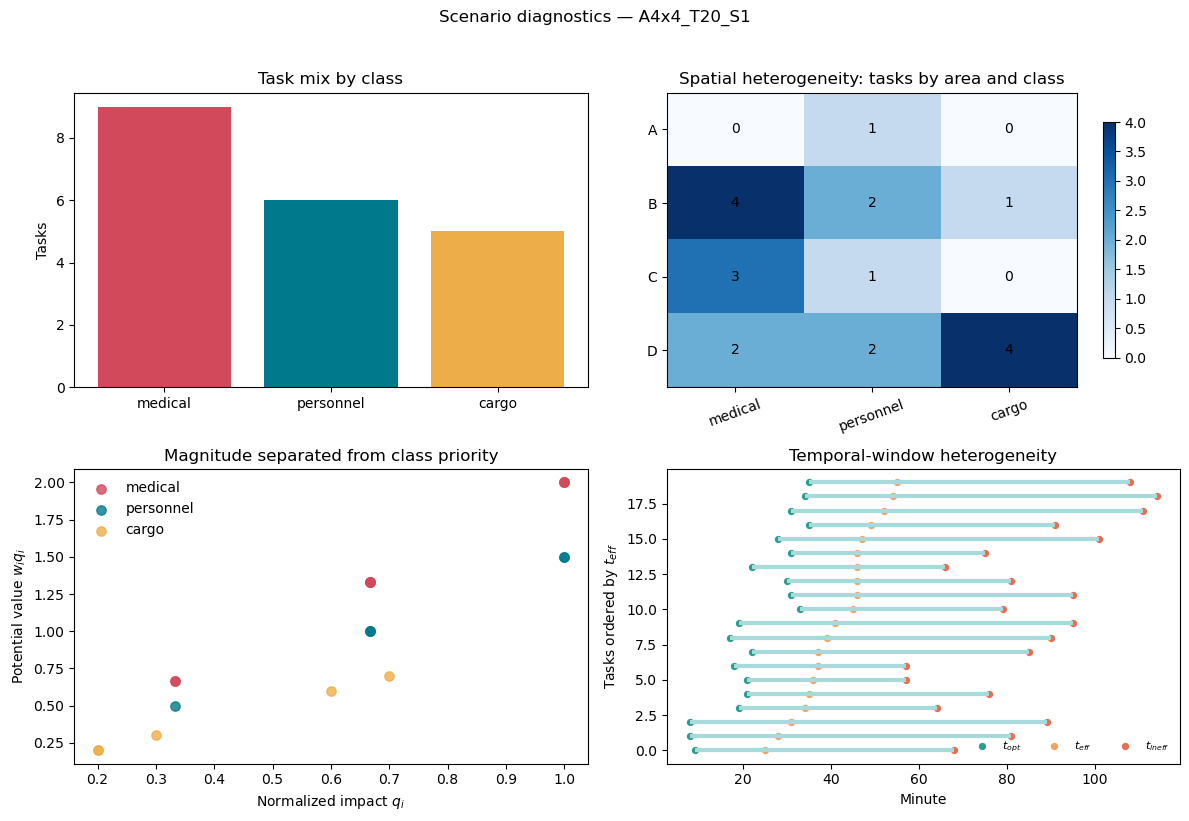

,Task ID,Area,Class,Visual Required,Raw Impact,Normalized Impact,Potential Value,t_opt,t_eff,t_ineff
0,1,C,medical,False,3.0,1.000000,2.000000,30.0,46.0,81.0
1,2,C,personnel,False,2.0,0.666667,1.000000,31.0,52.0,111.0
2,3,C,medical,False,2.0,0.666667,1.333333,35.0,55.0,108.0
3,4,C,medical,False,1.0,0.333333,0.666667,8.0,31.0,89.0
4,5,B,personnel,False,3.0,1.000000,1.500000,21.0,35.0,76.0
5,6,A,personnel,True,3.0,1.000000,1.500000,17.0,39.0,90.0
6,7,B,cargo,False,150.0,0.300000,0.300000,31.0,46.0,75.0
7,8,B,medical,False,2.0,0.666667,1.333333,35.0,49.0,91.0
8,9,D,medical,False,3.0,1.000000,2.000000,22.0,46.0,66.0
9,10,B,personnel,True,1.0,0.333333,0.500000,28.0,47.0,101.0


In [ ]:
# ============================================================
# 12. DESCRIPTIVE DIAGNOSTICS BEFORE OPTIMIZATION
# ============================================================

def scenario_task_dataframe(scenario):
    rows = []
    for task_id, task in scenario["tasks"].items():
        rows.append({
            "Task ID": task_id,
            "Area": scenario["task_to_node"][task_id],
            "Class": task["priority_class"],
            "Visual Required": task["visual"],
            "Raw Impact": task["raw_impact"],
            "Normalized Impact": task["impact"],
            "Potential Value": task["potential_value"],
            "t_opt": task["t_opt"],
            "t_eff": task["t_eff"],
            "t_ineff": task["t_ineff"],
        })
    return pd.DataFrame(rows)


def plot_scenario_diagnostics(scenario, save=True):
    df = scenario_task_dataframe(scenario)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    class_counts = df["Class"].value_counts().reindex(TASK_CLASS_NAMES, fill_value=0)
    axes[0, 0].bar(class_counts.index, class_counts.values, color=["#D1495B", "#00798C", "#EDAe49"])
    axes[0, 0].set_title("Task mix by class")
    axes[0, 0].set_ylabel("Tasks")

    area_class = pd.crosstab(df["Area"], df["Class"]).reindex(
        index=["A", "B", "C", "D"], columns=TASK_CLASS_NAMES, fill_value=0
    )
    image = axes[0, 1].imshow(area_class.values, cmap="Blues", aspect="auto")
    axes[0, 1].set_xticks(range(len(area_class.columns)), area_class.columns, rotation=20)
    axes[0, 1].set_yticks(range(len(area_class.index)), area_class.index)
    axes[0, 1].set_title("Spatial heterogeneity: tasks by area and class")
    for i in range(area_class.shape[0]):
        for j in range(area_class.shape[1]):
            axes[0, 1].text(j, i, int(area_class.iloc[i, j]), ha="center", va="center")
    fig.colorbar(image, ax=axes[0, 1], shrink=0.8)

    for task_class, color in zip(TASK_CLASS_NAMES, ["#D1495B", "#00798C", "#EDAe49"]):
        subset = df[df["Class"] == task_class]
        axes[1, 0].scatter(
            subset["Normalized Impact"], subset["Potential Value"],
            label=task_class, color=color, alpha=0.8, s=45,
        )
    axes[1, 0].set_xlabel("Normalized impact $q_i$")
    axes[1, 0].set_ylabel("Potential value $w_i q_i$")
    axes[1, 0].set_title("Magnitude separated from class priority")
    axes[1, 0].legend(frameon=False)

    ordered = df.sort_values("t_eff").reset_index(drop=True)
    y = np.arange(len(ordered))
    axes[1, 1].hlines(y, ordered["t_opt"], ordered["t_ineff"], color="#A8DADC", lw=3)
    axes[1, 1].scatter(ordered["t_opt"], y, color="#2A9D8F", s=18, label="$t_{opt}$")
    axes[1, 1].scatter(ordered["t_eff"], y, color="#F4A261", s=18, label="$t_{eff}$")
    axes[1, 1].scatter(ordered["t_ineff"], y, color="#E76F51", s=18, label="$t_{ineff}$")
    axes[1, 1].set_xlabel("Minute")
    axes[1, 1].set_ylabel("Tasks ordered by $t_{eff}$")
    axes[1, 1].set_title("Temporal-window heterogeneity")
    axes[1, 1].legend(frameon=False, ncol=3, fontsize=8)

    fig.suptitle(f"Scenario diagnostics — {scenario['scenario_id']}", y=1.02)
    fig.tight_layout()
    if save:
        save_current_figure("A0_scenario_diagnostics.png")
    plt.show()
    return df


df_scenario_check = plot_scenario_diagnostics(scenario_check)
display(df_scenario_check.head(10))


## 13. Ejecución del Experimento A

La progresión experimental queda explícita:

1. micropruebas matemáticas e interpretación de (q_i);
2. diagnóstico de una instancia 4×4;
3. comparación de tres políticas constructivas;
4. perfil HiGHS bajo presupuesto computacional;
5. escalamiento sobre 20–60 tareas y 30 semillas en modo `paper`;
6. interpretación operacional mediante rutas, cronogramas, impacto por clase y eficiencia de vuelo.


In [ ]:
# ============================================================
# 14. RUN EXPERIMENT A
# ============================================================

experiment_start = time.perf_counter()
df_metrics_scaling, df_logs_scaling, example_result = run_experiment_suite(
    task_sizes=ACTIVE_TASK_COUNTS,
    seeds=ACTIVE_SEEDS,
    highs_budgets=ACTIVE_HIGHS_BUDGETS,
    verbose=True,
)
experiment_runtime = time.perf_counter() - experiment_start

audit_experiment(
    df_metrics_scaling,
    df_logs_scaling,
    ACTIVE_TASK_COUNTS,
    ACTIVE_SEEDS,
    ACTIVE_HIGHS_BUDGETS,
)

metrics_path = OUTPUT_DIR / f"metrics_A4x4_{RUN_MODE}_{TASK_GENERATOR_VERSION}.csv"
logs_path = OUTPUT_DIR / f"task_logs_A4x4_{RUN_MODE}_{TASK_GENERATOR_VERSION}.csv"
df_metrics_scaling.to_csv(metrics_path, index=False)
df_logs_scaling.to_csv(logs_path, index=False)

print(f"Experiment runtime: {experiment_runtime:.2f} s")
print("Saved:", metrics_path)
print("Saved:", logs_path)
display(df_metrics_scaling)


[1/150] A4x4_T20_S1
Greedy-Benefit: H1 -> T1 at 19.0
Greedy-Benefit: H2 -> T9 at 29.0
Greedy-Benefit: H3 -> T6 at 11.0
Greedy-Benefit: H4 -> T5 at 16.0
Greedy-Benefit: H3 -> T7 at 24.0
Greedy-Benefit: H1 -> T16 at 31.0
Greedy-Benefit: H4 -> T12 at 44.0
Greedy-Benefit: H3 -> T3 at 57.0
Greedy-Benefit: H4 -> T2 at 55.0
Greedy-Benefit: H1 -> T8 at 67.0
Greedy-Benefit: H2 -> T4 at 76.0
Greedy-Benefit: H3 -> T10 at 68.0
Greedy-Benefit: H1 -> T15 at 82.0
Greedy-Density-Operational: H1 -> T6 at 11.0
Greedy-Density-Operational: H2 -> T1 at 22.0
Greedy-Density-Operational: H3 -> T5 at 17.0
Greedy-Density-Operational: H4 -> T9 at 23.0
Greedy-Density-Operational: H1 -> T7 at 23.0
Greedy-Density-Operational: H2 -> T16 at 36.0
Greedy-Density-Operational: H3 -> T12 at 47.0
Greedy-Density-Operational: H1 -> T3 at 54.0
Greedy-Density-Operational: H4 -> T8 at 58.0
Greedy-Density-Operational: H3 -> T2 at 58.0
Greedy-Density-Operational: H1 -> T10 at 65.0
Greedy-Density-Operational: H3 -> T15 at 71.0
Gre

KeyboardInterrupt: 

In [ ]:
# ============================================================
# 15. SUMMARY TABLES FOR ANALYSIS AND PAPER
# ============================================================

SUMMARY_METRICS = [
    "Normalized Mission Value",
    "Weighted Impact Coverage",
    "Physical Completed Tasks",
    "Medical Evacuees",
    "Personnel Transported",
    "Cargo Delivered kg",
    "Average Response Time",
    "Total Flight Time",
    "Runtime sec",
    "End-to-end sec",
    "MIP Gap",
]

summary_by_size = (
    df_metrics_scaling
    .groupby(["Tasks", "Method"], observed=True)[SUMMARY_METRICS]
    .agg(["mean", "std", "count"])
    .reset_index()
)

certification_summary = (
    df_metrics_scaling[df_metrics_scaling["Method"].str.startswith("HiGHS")]
    .groupby(["Tasks", "Method"], observed=True)
    .agg(
        Runs=("Scenario", "count"),
        Incumbents=("Normalized Mission Value", "count"),
        Certified=("Optimal Certified", "sum"),
        Mean_Primal=("Primal Bound", "mean"),
        Mean_Dual=("Dual Bound", "mean"),
        Mean_Gap=("MIP Gap", "mean"),
        Mean_Solver_sec=("Solver Time sec", "mean"),
        Mean_End_to_End_sec=("End-to-end sec", "mean"),
    )
    .reset_index()
)
certification_summary["Certification Rate"] = (
    certification_summary["Certified"] / certification_summary["Runs"]
)

print("Quality and operational summary")
display(summary_by_size)
print("Anytime and certification summary")
display(certification_summary)

summary_by_size.to_csv(OUTPUT_DIR / f"summary_A4x4_{RUN_MODE}.csv", index=False)
certification_summary.to_csv(OUTPUT_DIR / f"certification_A4x4_{RUN_MODE}.csv", index=False)


## 16. Figuras de calidad, impacto y escalamiento

Las figuras siguientes no son variaciones decorativas del mismo resultado. Cada una responde una pregunta distinta:

- ¿cuánto valor humanitario captura cada método?;
- ¿la mejora proviene de atender más tareas o de seleccionar tareas de mayor magnitud?;
- ¿qué clases reciben cobertura?;
- ¿qué valor adicional se obtiene al disponer de más tiempo de cómputo?;
- ¿cuánto cuesta esa mejora en vuelo y tiempo computacional?;
- ¿cómo crece la formulación y con qué frecuencia se certifica optimalidad?;


In [ ]:
# ============================================================
# 17. FIGURE A1 — QUALITY, IMPACT AND COMPLETED TASKS
# ============================================================

def mean_sd_table(df, metric):
    return (
        df.groupby(["Tasks", "Method"], observed=True)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )


def plot_quality_scaling(df, save=True):
    metrics = [
        ("Normalized Mission Value", "Normalized mission value"),
        ("Weighted Impact Coverage", "Weighted impact coverage"),
        ("Physical Completed Tasks", "Completed tasks"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    for ax, (metric, ylabel) in zip(axes, metrics):
        summary = mean_sd_table(df, metric)
        for method in METHOD_ORDER:
            subset = summary[summary["Method"] == method].sort_values("Tasks")
            if subset.empty:
                continue
            error = subset["std"].fillna(0.0)
            ax.errorbar(
                subset["Tasks"], subset["mean"], yerr=error,
                marker="o", capsize=3, lw=1.8,
                color=METHOD_COLORS.get(method), label=method,
            )
        ax.set_xlabel("Number of tasks")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
    axes[0].set_ylim(0, 1)
    axes[1].set_ylim(0, 1)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)), frameon=False)
    fig.suptitle("Experiment A: quality and humanitarian coverage", y=1.08)
    fig.tight_layout()
    if save:
        save_current_figure("A1_quality_impact_completed.png")
    plt.show()


plot_quality_scaling(df_metrics_scaling)


In [ ]:
# ============================================================
# 18. FIGURE A2 — CLASS-SPECIFIC IMPACT COVERAGE
# ============================================================

def plot_class_coverage(df, save=True):
    coverage_columns = {
        "Medical Impact Coverage": "Medical evacuees",
        "Personnel Impact Coverage": "Personnel transported",
        "Cargo Impact Coverage": "Cargo delivered",
    }
    melted = df.melt(
        id_vars=["Tasks", "Method"],
        value_vars=list(coverage_columns),
        var_name="Coverage Metric",
        value_name="Coverage",
    )
    melted["Class"] = melted["Coverage Metric"].map(coverage_columns)
    summary = (
        melted.groupby(["Tasks", "Method", "Class"], observed=True)["Coverage"]
        .mean().reset_index()
    )

    task_sizes = sorted(summary["Tasks"].unique())
    fig, axes = plt.subplots(1, len(task_sizes), figsize=(6 * len(task_sizes), 4.5), squeeze=False)
    for ax, n_tasks in zip(axes[0], task_sizes):
        subset = summary[summary["Tasks"] == n_tasks]
        methods = [m for m in METHOD_ORDER if m in set(subset["Method"])]
        classes = list(coverage_columns.values())
        x = np.arange(len(classes))
        width = 0.8 / max(1, len(methods))
        for index, method in enumerate(methods):
            values = (
                subset[subset["Method"] == method]
                .set_index("Class")["Coverage"]
                .reindex(classes)
                .values
            )
            ax.bar(
                x + (index - (len(methods) - 1) / 2) * width,
                values,
                width=width,
                label=method,
                color=METHOD_COLORS.get(method),
                alpha=0.82,
            )
        ax.set_xticks(x, classes, rotation=18, ha="right")
        ax.set_ylim(0, 1)
        ax.set_ylabel("Physical impact coverage")
        ax.set_title(f"{n_tasks} tasks")
        ax.grid(axis="y", alpha=0.25)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)), frameon=False)
    fig.suptitle("Who or what is served? Impact coverage by task class", y=1.08)
    fig.tight_layout()
    if save:
        save_current_figure("A2_class_impact_coverage.png")
    plt.show()


plot_class_coverage(df_metrics_scaling)


In [ ]:
# ============================================================
# 19. FIGURE A3 — ANYTIME PROFILE AND CERTIFICATION
# ============================================================

def method_budget(method):
    if not method.startswith("HiGHS-"):
        return np.nan
    return float(method.replace("HiGHS-", "").replace("s", ""))


def plot_anytime_profile(df, save=True):
    exact = df[df["Method"].str.startswith("HiGHS")].copy()
    exact["Budget"] = exact["Method"].map(method_budget)
    greedy_best = (
        df[df["Method"].str.startswith("Greedy")]
        .groupby(["Scenario", "Tasks"], observed=True)["Normalized Mission Value"]
        .max().reset_index(name="Best Greedy")
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for n_tasks, subset in exact.groupby("Tasks"):
        quality = subset.groupby("Budget")["Normalized Mission Value"].agg(["mean", "std"]).reset_index()
        gap = subset.groupby("Budget")["MIP Gap"].mean().reset_index()
        certification = subset.groupby("Budget")["Optimal Certified"].mean().reset_index()
        valid_quality = quality.dropna(subset=["mean"])
        if not valid_quality.empty:
            axes[0].plot(valid_quality["Budget"], valid_quality["mean"], marker="o", label=f"{n_tasks} tasks")
            axes[0].fill_between(
                valid_quality["Budget"],
                valid_quality["mean"] - valid_quality["std"].fillna(0),
                valid_quality["mean"] + valid_quality["std"].fillna(0),
                alpha=0.15,
            )
        valid_gap = gap.dropna(subset=["MIP Gap"])
        if not valid_gap.empty:
            axes[1].plot(valid_gap["Budget"], valid_gap["MIP Gap"], marker="o", label=f"{n_tasks} tasks")
        axes[2].plot(certification["Budget"], certification["Optimal Certified"], marker="o", label=f"{n_tasks} tasks")

    greedy_level = greedy_best["Best Greedy"].mean()
    axes[0].axhline(greedy_level, color="#6C757D", ls="--", lw=1.5, label="Mean best Greedy")
    axes[0].set_ylabel("Normalized mission value")
    axes[1].set_ylabel("Mean MIP gap")
    axes[2].set_ylabel("Certification rate")
    axes[0].set_ylim(0, 1)
    axes[1].set_ylim(bottom=0)
    axes[2].set_ylim(0, 1.02)
    budgets = np.asarray(sorted(exact["Budget"].dropna().unique()), dtype=float)
    for ax in axes:
        ax.set_xscale("log")
        if len(budgets):
            ax.set_xlim(budgets.min() / 1.35, budgets.max() * 1.35)
            ax.set_xticks(budgets, [f"{value:g}" for value in budgets])
        ax.set_xlabel("HiGHS time limit (s, log scale)")
        ax.grid(alpha=0.25)
    if exact["Normalized Mission Value"].notna().sum() == 0:
        axes[0].text(0.5, 0.55, "No HiGHS incumbent within tested budgets", transform=axes[0].transAxes, ha="center")
    if exact["MIP Gap"].notna().sum() == 0:
        axes[1].text(0.5, 0.55, "Gap unavailable until an incumbent exists", transform=axes[1].transAxes, ha="center")
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle("Anytime profile: primal quality, certification gap and proof", y=1.03)
    fig.tight_layout()
    if save:
        save_current_figure("A3_anytime_profile.png")
    plt.show()


plot_anytime_profile(df_metrics_scaling)


In [ ]:
# ============================================================
# 20. FIGURE A4 — OPERATIONAL AND COMPUTATIONAL TRADE-OFFS
# ============================================================

def plot_tradeoffs(df, save=True):
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))
    for method in METHOD_ORDER:
        subset = df[df["Method"] == method]
        if subset.empty:
            continue
        axes[0].scatter(
            subset["Total Flight Time"], subset["Normalized Mission Value"],
            label=method, alpha=0.7, s=35, color=METHOD_COLORS.get(method),
        )
        summary = subset.groupby("Tasks")["Runtime sec"].mean().reset_index()
        axes[1].plot(
            summary["Tasks"], summary["Runtime sec"], marker="o",
            label=method, color=METHOD_COLORS.get(method),
        )
        efficiency = subset.groupby("Tasks")["Value per Flight Minute"].mean().reset_index()
        axes[2].plot(
            efficiency["Tasks"], efficiency["Value per Flight Minute"], marker="o",
            label=method, color=METHOD_COLORS.get(method),
        )
    axes[0].set_xlabel("Total flight time (min)")
    axes[0].set_ylabel("Normalized mission value")
    axes[0].set_title("Primal value versus flight effort")
    axes[1].set_xlabel("Number of tasks")
    axes[1].set_ylabel("Method runtime (s, log scale)")
    axes[1].set_yscale("log")
    axes[1].set_title("Computational cost")
    axes[2].set_xlabel("Number of tasks")
    axes[2].set_ylabel("Mission value / flight minute")
    axes[2].set_title("Operational efficiency")
    for ax in axes:
        ax.grid(alpha=0.25)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)), frameon=False)
    fig.suptitle("Operational and computational trade-offs", y=1.08)
    fig.tight_layout()
    if save:
        save_current_figure("A4_tradeoffs.png")
    plt.show()


plot_tradeoffs(df_metrics_scaling)


In [ ]:
# ============================================================
# 21. FIGURE A5 — MILP GROWTH AND DENSITY ADVANTAGE
# ============================================================

def plot_model_growth_and_paired_advantage(df, save=True):
    exact = df[df["Method"].str.startswith("HiGHS")].copy()
    growth = (
        exact.groupby(["Scenario", "Tasks"], observed=True)
        .agg(Variables=("Variables", "first"), Constraints=("Constraints", "first"), Nonzeros=("Nonzeros", "first"))
        .reset_index()
        .groupby("Tasks")[["Variables", "Constraints", "Nonzeros"]]
        .mean().reset_index()
    )

    pivot = df.pivot(index=["Scenario", "Tasks"], columns="Method", values="Normalized Mission Value")
    differences = []
    comparisons = [
        ("Greedy-Density-Operational", "Greedy-Benefit", "Density-operational − Benefit"),
        ("Greedy-Density-Cycle", "Greedy-Benefit", "Density-cycle − Benefit"),
    ]
    best_highs = f"HiGHS-{max(ACTIVE_HIGHS_BUDGETS):g}s"
    comparisons.append((best_highs, "Greedy-Density-Operational", f"{best_highs} − Density-operational"))
    for left, right, label in comparisons:
        if left in pivot.columns and right in pivot.columns:
            values = (pivot[left] - pivot[right]).dropna()
            for (scenario, tasks), value in values.items():
                differences.append({"Scenario": scenario, "Tasks": tasks, "Comparison": label, "Difference": value})
    diff_df = pd.DataFrame(differences)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    axes[0].plot(growth["Tasks"], growth["Variables"], marker="o", label="Variables")
    axes[0].plot(growth["Tasks"], growth["Constraints"], marker="s", label="Constraints")
    axes[0].plot(growth["Tasks"], growth["Nonzeros"], marker="^", label="Nonzeros")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Number of tasks")
    axes[0].set_ylabel("Mean count (log scale)")
    axes[0].set_title("State–arc MILP growth")
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.25)

    if not diff_df.empty:
        labels = list(diff_df["Comparison"].unique())
        data = [diff_df[diff_df["Comparison"] == label]["Difference"] for label in labels]
        axes[1].boxplot(data, labels=labels, showmeans=True)
        axes[1].axhline(0, color="black", lw=1)
        axes[1].tick_params(axis="x", rotation=18)
    axes[1].set_ylabel("Paired mission-value difference")
    axes[1].set_title("Does each methodological addition help?")
    axes[1].grid(axis="y", alpha=0.25)
    fig.tight_layout()
    if save:
        save_current_figure("A5_model_growth_paired_advantage.png")
    plt.show()
    return diff_df


df_paired_advantage = plot_model_growth_and_paired_advantage(df_metrics_scaling)
display(df_paired_advantage.groupby("Comparison")["Difference"].agg(["mean", "std", "min", "max", "count"]) if not df_paired_advantage.empty else df_paired_advantage)


## 22. Interpretabilidad operacional de una instancia

Los promedios no permiten verificar si una política genera secuencias razonables. Por eso se incluyen:

- mapa de rutas por helicóptero y método;
- cronograma tipo Gantt;
- curvas acumuladas de valor capturado;
- marcas de retorno y recuperación.

Estas figuras se construyen con la primera instancia ejecutada y no intervienen en la optimización.


In [ ]:
# ============================================================
# 23. FIGURE A6 — ROUTE MAPS
# ============================================================

HELO_COLORS = {1: "#1D3557", 2: "#E63946", 3: "#2A9D8F", 4: "#F4A261"}


def plot_route_maps(result, save=True):
    scenario = result["scenario"]
    best_highs = f"HiGHS-{max(ACTIVE_HIGHS_BUDGETS):g}s"
    methods = [
        "Greedy-Benefit",
        "Greedy-Density-Operational",
        "Greedy-Density-Cycle",
        best_highs,
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for ax, method in zip(axes.flat, methods):
        df = result["method_logs"].get(method, pd.DataFrame())
        task_labels = defaultdict(list)
        for node, (x, y) in scenario["nodes"].items():
            marker = "*" if node == "Base" else "o"
            size = 190 if node == "Base" else 95
            ax.scatter(x, y, marker=marker, s=size, color="black" if node == "Base" else "white", edgecolor="black", zorder=4)
            ax.text(x + 0.8, y + 0.6, node, fontsize=9)
        if df is not None and not df.empty:
            for helo_id, helo_df in df.groupby("Helo ID"):
                helo_df = helo_df.sort_values("Completion Time")
                for _, row in helo_df.iterrows():
                    x0, y0 = scenario["nodes"][row["Start Node"]]
                    x1, y1 = scenario["nodes"][row["Node"]]
                    ax.annotate(
                        "", xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="->", color=HELO_COLORS[int(helo_id)], lw=1.6, alpha=0.8),
                    )
                    if row["Status"] == "Task Executed":
                        task_labels[(int(helo_id), row["Node"])].append(int(row["Task ID"]))
        label_offsets = {
            1: (-2.6, -1.8),
            2: (0.5, -1.8),
            3: (-2.6, 1.0),
            4: (0.5, 1.0),
        }
        for (helo_id, node), task_ids in task_labels.items():
            x, y = scenario["nodes"][node]
            dx, dy = label_offsets[helo_id]
            sequence = ",".join(str(task_id) for task_id in task_ids)
            ax.text(
                x + dx, y + dy, f"H{helo_id}: {sequence}",
                fontsize=6.5, color=HELO_COLORS[helo_id],
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=0.5),
                zorder=5,
            )
        ax.set_title(method)
        ax.set_xlabel("Cartesian x")
        ax.set_ylabel("Cartesian y")
        ax.grid(alpha=0.2)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-4, 44)
        ax.set_ylim(-4, 24)
    fig.suptitle(f"Route interpretation — {scenario['scenario_id']}", y=0.99)
    fig.tight_layout()
    if save:
        save_current_figure("A6_route_maps.png")
    plt.show()


plot_route_maps(example_result)


In [ ]:
# ============================================================
# 24. FIGURE A7 — GANTT AND CUMULATIVE VALUE
# ============================================================

def plot_gantt_and_value(result, save=True):
    best_highs = f"HiGHS-{max(ACTIVE_HIGHS_BUDGETS):g}s"
    methods = ["Greedy-Benefit", "Greedy-Density-Operational", "Greedy-Density-Cycle", best_highs]
    fig, axes = plt.subplots(len(methods), 2, figsize=(14, 3.2 * len(methods)))
    for row_index, method in enumerate(methods):
        df = result["method_logs"].get(method, pd.DataFrame())
        gantt_ax, value_ax = axes[row_index]
        if df is None or df.empty:
            gantt_ax.text(0.5, 0.5, "No incumbent", transform=gantt_ax.transAxes, ha="center")
            value_ax.text(0.5, 0.5, "No incumbent", transform=value_ax.transAxes, ha="center")
            continue

        for _, event in df.sort_values("Start Time").iterrows():
            helo = int(event["Helo ID"])
            duration = event["Completion Time"] - event["Start Time"]
            color = HELO_COLORS[helo] if event["Status"] == "Task Executed" else "#BDBDBD"
            gantt_ax.barh(helo, duration, left=event["Start Time"], height=0.55, color=color, alpha=0.85)
            label = f"T{int(event['Task ID'])}" if event["Status"] == "Task Executed" else "R"
            gantt_ax.text(event["Start Time"] + duration / 2, helo, label, ha="center", va="center", fontsize=7)

        task_df = df[df["Status"] == "Task Executed"].sort_values("Completion Time").copy()
        task_df["Cumulative Value"] = task_df["Benefit"].cumsum()
        value_ax.step(task_df["Completion Time"], task_df["Cumulative Value"], where="post", color="#264653", lw=2)
        value_ax.scatter(task_df["Completion Time"], task_df["Cumulative Value"], color="#264653", s=18)

        gantt_ax.set_yticks([1, 2, 3, 4], ["H1", "H2", "H3", "H4"])
        gantt_ax.set_ylabel(method)
        gantt_ax.set_xlabel("Minute")
        gantt_ax.grid(axis="x", alpha=0.2)
        value_ax.set_xlabel("Completion minute")
        value_ax.set_ylabel("Cumulative mission value")
        value_ax.set_ylim(bottom=0)
        value_ax.grid(alpha=0.2)
    axes[0, 0].set_title("Mission timeline (R = return/recovery)")
    axes[0, 1].set_title("When is humanitarian value captured?")
    fig.tight_layout()
    if save:
        save_current_figure("A7_gantt_cumulative_value.png")
    plt.show()


plot_gantt_and_value(example_result)


## 25. Lectura recomendada de los resultados

No debe concluirse que un método es superior usando solo “tareas completadas”. La interpretación propuesta es:

1. **Calidad primal:** `Normalized Mission Value`.
2. **Resultado físico:** evacuados médicos, personas transportadas y kg entregados.
3. **Equidad entre clases:** coberturas médica, personal y carga.
4. **Oportunidad:** tiempos de respuesta y diferencia entre cobertura ponderada sin tiempo y valor con (S_i(t)).
5. **Eficiencia operacional:** valor por minuto de vuelo y tiempo total de vuelo.
6. **Disponibilidad computacional:** calidad y *gap* a 1/5/15/60 s.
7. **Certificación:** separar siempre “incumbent factible” de “óptimo certificado”.

### Cómo responde este Experimento A a los profesores

- La función objetivo ya distingue magnitud dentro de una misma clase.
- El Greedy original queda como baseline miope, no como heurística fuerte.
- Se comparan dos definiciones transparentes de densidad.
- HiGHS se evalúa como método *anytime*, no solo como “exacto lento”.
- La progresión parte por validación controlada 4×4 y termina en escalamiento.
- El notebook muestra qué personas/carga se atienden, cuándo, con qué vuelo y con qué nivel de certificación.

### Limitaciones deliberadas de esta versión

- La severidad médica no se modela aparte de la función temporal.
- Las tareas se conocen al inicio del horizonte: modelo determinista *offline*.
- Combustible, incertidumbre, llegadas dinámicas y *rolling horizon* quedan fuera del Experimento A.
- El *warm start* requiere migrar desde la interfaz SciPy a `highspy` y debe estudiarse en un experimento pareado separado.
